CELL 1

In [ ]:
# ====================================================================
# 1. SETUP ENVIRONMENT
# ====================================================================

from google.colab import drive
drive.mount('/content/drive')

print("📦 Sedang menyalin dan mengekstrak dataset ke lokal Colab...")

!cp "/content/drive/MyDrive/DATASET_UJICOBA.zip" "/content/"
!unzip -q "/content/DATASET_UJICOBA.zip" -d "/content/dataset_lokal"

print("✅ Dataset berhasil dipindahkan ke lokal Colab!\n")

import os
import cv2
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ====================================================================
# Menentukan path dataset
# ====================================================================

base_path = '/content/dataset_lokal/DATASET_UJICOBA'

train_gingivitis_dir = os.path.join(base_path, 'Gingivitis')
train_non_gingivitis_dir = os.path.join(base_path, 'Non_Gingivitis')

print("📍 Jalur dataset:")
print(f"Gingivitis      : {train_gingivitis_dir}")
print(f"Non_Gingivitis  : {train_non_gingivitis_dir}")

print("\n🔍 Verifikasi:")
print("Gingivitis ada?      :", os.path.exists(train_gingivitis_dir))
print("Non_Gingivitis ada?  :", os.path.exists(train_non_gingivitis_dir))

Mounted at /content/drive
📦 Sedang menyalin dan mengekstrak dataset ke lokal Colab...
✅ Dataset berhasil dipindahkan ke lokal Colab!

📍 Jalur dataset:
Gingivitis      : /content/dataset_lokal/DATASET_UJICOBA/Gingivitis
Non_Gingivitis  : /content/dataset_lokal/DATASET_UJICOBA/Non_Gingivitis

🔍 Verifikasi:
Gingivitis ada?      : True
Non_Gingivitis ada?  : True


CELL 2

--- Jumlah Data Awal ---
Jumlah citra Gingivitis     : 600
Jumlah citra Non-Gingivitis : 600
Total Keseluruhan           : 1200

Menampilkan Sampel Acak:


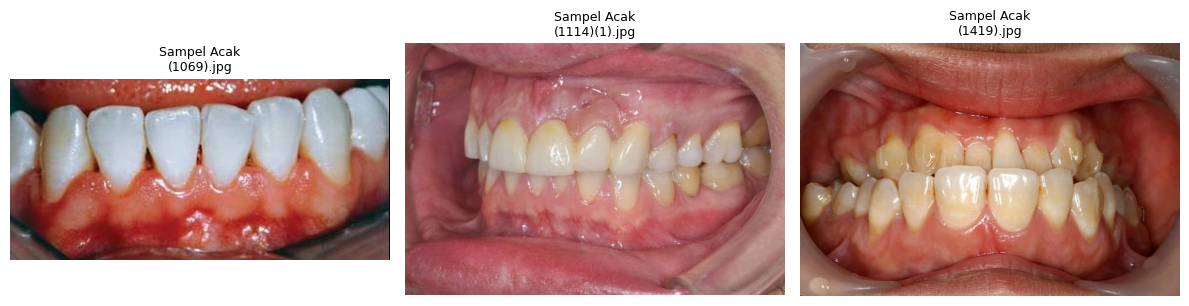

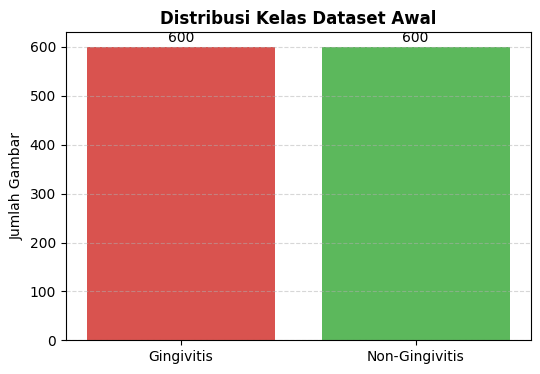

In [ ]:
# ==========================================
# 2. DATA UNDERSTANDING
# ==========================================

# A. Menghitung Jumlah File
def count_files(directory):
    return len([
        f for f in os.listdir(directory)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

total_gingivitis = count_files(train_gingivitis_dir)
total_non = count_files(train_non_gingivitis_dir)

print("--- Jumlah Data Awal ---")
print(f"Jumlah citra Gingivitis     : {total_gingivitis}")
print(f"Jumlah citra Non-Gingivitis : {total_non}")
print(f"Total Keseluruhan           : {total_gingivitis + total_non}\n")


# B. Visualisasi Sampel Secara Acak
def intip_dataset_random(jumlah_sampel=3):

    semua_file = [
        f for f in os.listdir(train_gingivitis_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    jumlah_sampel = min(jumlah_sampel, len(semua_file))
    sampel_pilihan = random.sample(semua_file, jumlah_sampel)

    plt.figure(figsize=(12, 4))

    for i, nama_file in enumerate(sampel_pilihan):

        path_foto = os.path.join(train_gingivitis_dir, nama_file)

        img = cv2.imread(path_foto)

        if img is None:
            print(f"Gagal membaca: {nama_file}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, jumlah_sampel, i+1)
        plt.imshow(img)
        plt.title(f"Sampel Acak\n{nama_file}", fontsize=9)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


print("Menampilkan Sampel Acak:")
intip_dataset_random()


# C. Cek Distribusi Kelas
plt.figure(figsize=(6, 4))

bars = plt.bar(
    ['Gingivitis', 'Non-Gingivitis'],
    [total_gingivitis, total_non],
    color=['#d9534f', '#5cb85c']
)

plt.title('Distribusi Kelas Dataset Awal', fontweight='bold')
plt.ylabel('Jumlah Gambar')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 5,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.show()

CELL 3

--- Hasil Akhir Pembagian Data (70:15:15) ---
Data Latih (Train)   : 840 gambar
Data Validasi (Val)  : 180 gambar
Data Uji (Test)      : 180 gambar

--- Persentase Pembagian Data ---
Train      : 840 (70.00%)
Validation : 180 (15.00%)
Test       : 180 (15.00%)

--- Distribusi Kelas ---
Train      -> Gingivitis: 420, Non-Gingivitis: 420
Validation -> Gingivitis: 90, Non-Gingivitis: 90
Test       -> Gingivitis: 90, Non-Gingivitis: 90


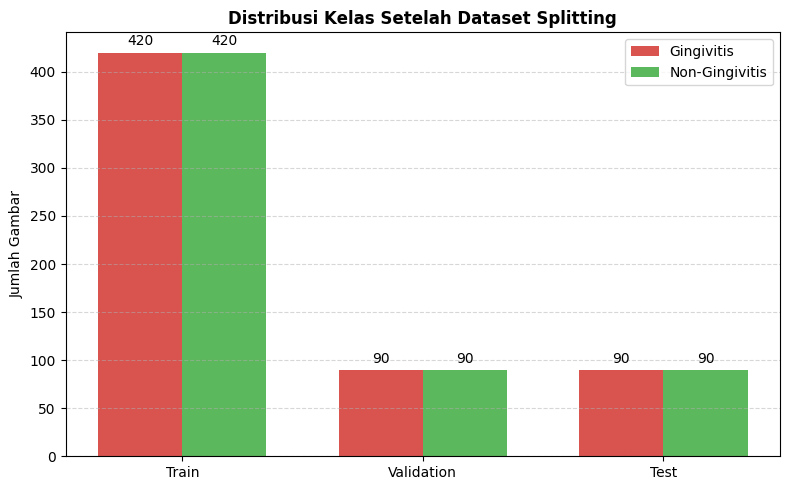

In [ ]:
# ==========================================
# 3. DATA PREPARATION
# ==========================================

import random
random.seed(42)
np.random.seed(42)

# ==========================================================
# A. Kumpulkan Path dan Label (Label Encoding)
# ==========================================================
all_paths = []
all_labels = []

# Kelas Gingivitis = 0
for img_name in sorted(os.listdir(train_gingivitis_dir)):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_paths.append(os.path.join(train_gingivitis_dir, img_name))
        all_labels.append(0)

# Kelas Non-Gingivitis = 1
for img_name in sorted(os.listdir(train_non_gingivitis_dir)):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        all_paths.append(os.path.join(train_non_gingivitis_dir, img_name))
        all_labels.append(1)


# ==========================================================
# B. Tahap 1: Pisahkan 15% untuk Test Set
# ==========================================================
X_temp_paths, X_test_paths, y_temp, y_test = train_test_split(
    all_paths,
    all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)


# ==========================================================
# C. Tahap 2:
# Dari sisa 85%, ambil 17.647% untuk Validation
# sehingga menghasilkan:
# Train = 70%
# Validation = 15%
# ==========================================================
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.17647,
    random_state=42,
    stratify=y_temp
)


# ==========================================================
# D. Menampilkan Hasil Split
# ==========================================================
print("--- Hasil Akhir Pembagian Data (70:15:15) ---")
print(f"Data Latih (Train)   : {len(X_train_paths)} gambar")
print(f"Data Validasi (Val)  : {len(X_val_paths)} gambar")
print(f"Data Uji (Test)      : {len(X_test_paths)} gambar\n")


# ==========================================================
# E. Menampilkan Persentase
# ==========================================================
total_data = len(all_paths)

print("--- Persentase Pembagian Data ---")
print(f"Train      : {len(X_train_paths)} ({len(X_train_paths)/total_data*100:.2f}%)")
print(f"Validation : {len(X_val_paths)} ({len(X_val_paths)/total_data*100:.2f}%)")
print(f"Test       : {len(X_test_paths)} ({len(X_test_paths)/total_data*100:.2f}%)\n")


# ==========================================================
# F. Menampilkan Distribusi Kelas
# ==========================================================
print("--- Distribusi Kelas ---")
print(f"Train      -> Gingivitis: {y_train.count(0)}, Non-Gingivitis: {y_train.count(1)}")
print(f"Validation -> Gingivitis: {y_val.count(0)}, Non-Gingivitis: {y_val.count(1)}")
print(f"Test       -> Gingivitis: {y_test.count(0)}, Non-Gingivitis: {y_test.count(1)}")


# ==========================================================
# G. Visualisasi Distribusi Setelah Split
# ==========================================================
categories = ['Train', 'Validation', 'Test']

gingivitis_counts = [
    y_train.count(0),
    y_val.count(0),
    y_test.count(0)
]

non_gingivitis_counts = [
    y_train.count(1),
    y_val.count(1),
    y_test.count(1)
]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(8,5))

rects1 = plt.bar(
    x - width/2,
    gingivitis_counts,
    width,
    label='Gingivitis',
    color='#d9534f'
)

rects2 = plt.bar(
    x + width/2,
    non_gingivitis_counts,
    width,
    label='Non-Gingivitis',
    color='#5cb85c'
)

plt.ylabel('Jumlah Gambar')
plt.title(
    'Distribusi Kelas Setelah Dataset Splitting',
    fontweight='bold'
)

plt.xticks(x, categories)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(
            f'{height}',
            xy=(rect.get_x() + rect.get_width()/2, height),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom'
        )

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

CELL 4

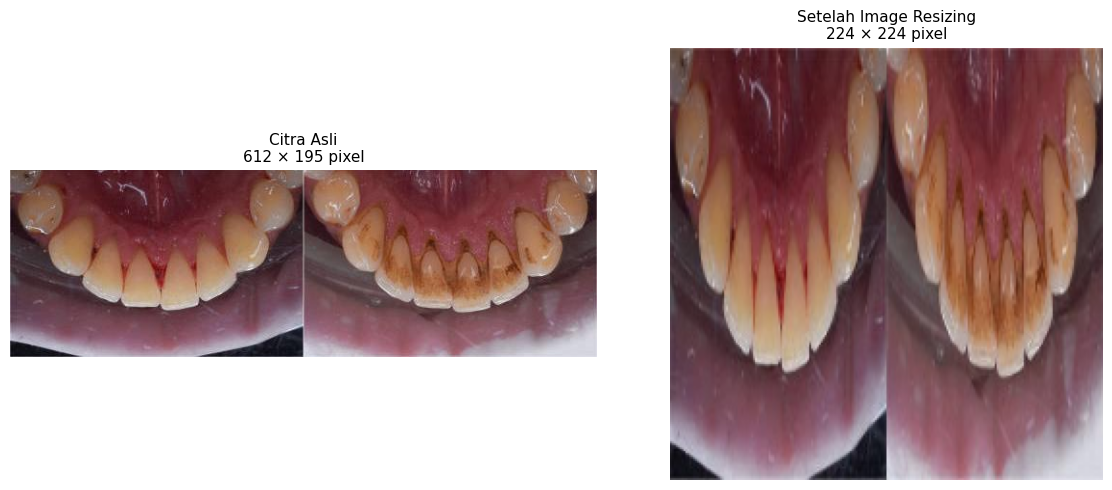

In [ ]:
# ==========================================================
# Visualisasi Image Resizing
# ==========================================================

import random
import cv2
import matplotlib.pyplot as plt
import os

# Ambil satu gambar secara acak
sample_path = random.choice(X_train_paths)

# Nama file
nama_file = os.path.basename(sample_path)

# Baca gambar asli
img_bgr = cv2.imread(sample_path)

# Konversi ke RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Simpan ukuran asli
h, w = img_rgb.shape[:2]

# Resize menjadi 224x224
img_resize = cv2.resize(
    img_rgb,
    (224, 224)
)

# ==========================================
# Visualisasi
# ==========================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title(
    f"Citra Asli\n{w} × {h} pixel",
    fontsize=11
)
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_resize)
plt.title(
    "Setelah Image Resizing\n224 × 224 pixel",
    fontsize=11
)
plt.axis("off")

plt.tight_layout()
plt.show()

✅ Fungsi Preprocessing siap digunakan!


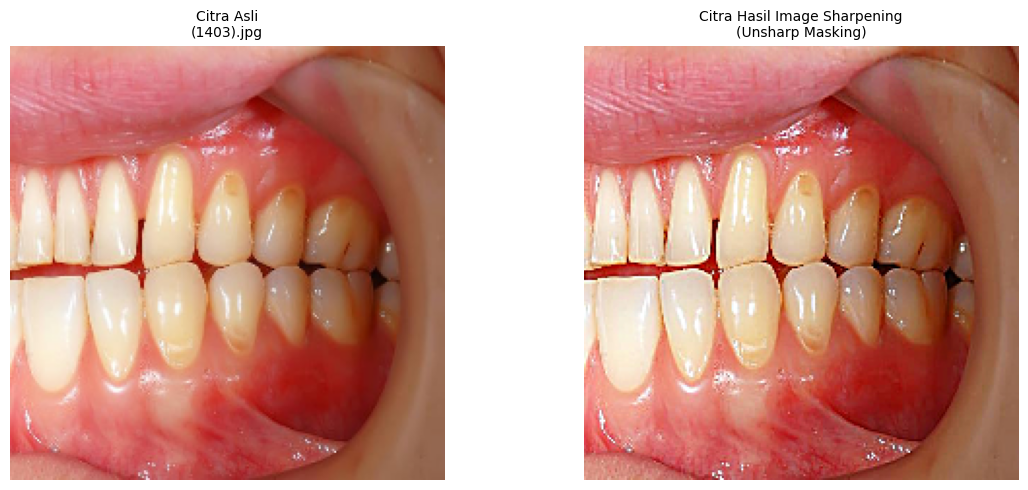

In [ ]:
# ==========================================
# 4. PREPROCESSING FUNCTION
# ==========================================

import tensorflow as tf
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt

# ==========================================
# Fungsi Load dan Preprocessing
# ==========================================
def load_and_preprocess(path, label, apply_sharpening=True):

    # Membaca gambar
    image = tf.io.read_file(path)
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Resize menjadi 224x224
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [224, 224])

    # ==========================================
    # OpenCV Processing
    # ==========================================
    def opencv_preprocessing(img_tensor):

        # Convert Tensor menjadi NumPy
        img_numpy = img_tensor.numpy().astype(np.uint8)

        # ==========================================
        # Image Sharpening (Unsharp Masking)
        # ==========================================
        if apply_sharpening:

            blurred = cv2.GaussianBlur(
                img_numpy,
                (5, 5),
                1.0
            )

            img_numpy = cv2.addWeighted(
                img_numpy,
                1.5,       # alpha (original image)
                blurred,
                -0.5,      # beta (blurred image)
                0          # gamma
            )

            # Menjaga nilai pixel tetap 0-255
            img_numpy = np.clip(
                img_numpy,
                0,
                255
            ).astype(np.uint8)

        # Normalisasi
        img_numpy = img_numpy.astype(np.float32) / 255.0

        return img_numpy

    image = tf.py_function(
        opencv_preprocessing,
        [image],
        tf.float32
    )

    image.set_shape((224, 224, 3))

    return image, label


# ==========================================
# Visualisasi Perbandingan
# ==========================================
def visualisasi_perbandingan_raw_sharp():

    test_path = random.choice(X_train_paths)
    nama_file = os.path.basename(test_path)

    img_bgr = cv2.imread(test_path)

    if img_bgr is None:
        print("Gagal membaca gambar.")
        return

    img_res = cv2.resize(
        img_bgr,
        (224, 224)
    )

    # Unsharp Masking
    blurred = cv2.GaussianBlur(
        img_res,
        (5, 5),
        2.0
    )

    img_sharp = cv2.addWeighted(
        img_res,
        2.0,
        blurred,
        -1.0,
        0
    )

    img_sharp = np.clip(
        img_sharp,
        0,
        255
    ).astype(np.uint8)

    # ==========================================
    # Plot
    # ==========================================
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(
        img_res,
        cv2.COLOR_BGR2RGB
    ))
    plt.title(
        f"Citra Asli\n{nama_file}",
        fontsize=10
    )
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(
        img_sharp,
        cv2.COLOR_BGR2RGB
    ))
    plt.title(
        "Citra Hasil Image Sharpening\n(Unsharp Masking)",
        fontsize=10
    )
    plt.axis('off')

    plt.tight_layout()
    plt.show()


print("✅ Fungsi Preprocessing siap digunakan!")
visualisasi_perbandingan_raw_sharp()

CELL 5

In [ ]:
# ==========================================
# 5. DATA PIPELINE
# ==========================================

batch_size = 32

# ========================================================
# SKENARIO A: TANPA SHARPENING
# ========================================================

train_ds_raw = (
    tf.data.Dataset.from_tensor_slices(
        (X_train_paths, y_train)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=False
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(len(X_train_paths))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_raw = (
    tf.data.Dataset.from_tensor_slices(
        (X_val_paths, y_val)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=False
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds_raw = (
    tf.data.Dataset.from_tensor_slices(
        (X_test_paths, y_test)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=False
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# ========================================================
# SKENARIO B: DENGAN SHARPENING
# ========================================================

train_ds_sharp = (
    tf.data.Dataset.from_tensor_slices(
        (X_train_paths, y_train)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(len(X_train_paths))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_sharp = (
    tf.data.Dataset.from_tensor_slices(
        (X_val_paths, y_val)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds_sharp = (
    tf.data.Dataset.from_tensor_slices(
        (X_test_paths, y_test)
    )
    .map(
        lambda x, y: load_and_preprocess(
            x,
            y,
            apply_sharpening=True
        ),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

print("--- Seluruh Pipeline Dataset Berhasil Dibuat ---")
print("✅ Raw Dataset   : train_ds_raw, val_ds_raw, test_ds_raw")
print("✅ Sharp Dataset : train_ds_sharp, val_ds_sharp, test_ds_sharp")

--- Seluruh Pipeline Dataset Berhasil Dibuat ---
✅ Raw Dataset   : train_ds_raw, val_ds_raw, test_ds_raw
✅ Sharp Dataset : train_ds_sharp, val_ds_sharp, test_ds_sharp


In [ ]:
for images, labels in train_ds_sharp.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


CELL 6

In [ ]:
# ==========================================
# 6. MEMBANGUN MODEL ALEXNET
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import AdamW

# Agar hasil eksperimen dapat direproduksi
tf.keras.utils.set_random_seed(42)


# ==========================================================
# Fungsi Membangun AlexNet Original
# ==========================================================
def build_alexnet(nama_model):

    model = Sequential(name=nama_model)

    # ======================================================
    # Feature Extraction
    # ======================================================

    model.add(
        Conv2D(
            filters=96,
            kernel_size=(11, 11),
            strides=(4, 4),
            activation='relu',
            input_shape=(224, 224, 3)
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    model.add(
        Conv2D(
            filters=256,
            kernel_size=(5, 5),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    model.add(
        Conv2D(
            filters=384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        Conv2D(
            filters=384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        Conv2D(
            filters=256,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        )
    )

    model.add(
        MaxPooling2D(
            pool_size=(3, 3),
            strides=(2, 2)
        )
    )

    # ======================================================
    # Classification
    # ======================================================

    model.add(Flatten())

    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))

    # Binary Classification
    model.add(Dense(1, activation='sigmoid'))

    return model


# ==========================================================
# AlexNet - Data Original
# ==========================================================
model_alexnet_raw = build_alexnet(
    "AlexNet_Skenario_Raw"
)

model_alexnet_raw.compile(
    optimizer=AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


# ==========================================================
# AlexNet - Data Sharpening
# ==========================================================
model_alexnet_sharp = build_alexnet(
    "AlexNet_Skenario_Sharp"
)

model_alexnet_sharp.compile(
    optimizer=AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✅ Dua Skenario Model AlexNet Berhasil Dibangun!")

print("\nRingkasan Model AlexNet (Raw)")
model_alexnet_raw.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Dua Skenario Model AlexNet Berhasil Dibangun!

Ringkasan Model AlexNet (Raw)


Model: "AlexNet_Skenario_Raw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,751,105 (178.34 MB)

 Trainable params: 46,751,105 (178.34 MB)

 Non-trainable params: 0 (0.00 B)

CELL 7

In [ ]:
# ==========================================
# 7. MODELING: MOBILENETV2 (TRANSFER LEARNING)
# ==========================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

tf.keras.utils.set_random_seed(42)

# ==========================================================
# Fungsi Membangun MobileNetV2
# ==========================================================
def build_mobilenetv2(nama_model):

    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Transfer Learning (Feature Extraction)
    base_model.trainable = False

    model = Sequential(name=nama_model)

    model.add(base_model)
    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))

    # Binary Classification
    model.add(Dense(1, activation='sigmoid'))

    return model


# ==========================================================
# MobileNetV2 - Data Original
# ==========================================================
model_mobilenet_raw = build_mobilenetv2(
    "MobileNetV2_Skenario_Raw"
)

model_mobilenet_raw.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)


# ==========================================================
# MobileNetV2 - Data Sharpening
# ==========================================================
model_mobilenet_sharp = build_mobilenetv2(
    "MobileNetV2_Skenario_Sharp"
)

model_mobilenet_sharp.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-5,
        weight_decay=1e-4
    ),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

print("✅ Dua Skenario Model MobileNetV2 Berhasil Dibangun!")
print("✅ Hyperparameter sudah disamakan dengan AlexNet.")

print("\nRingkasan Model MobileNetV2 (Raw)")
model_mobilenet_raw.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Dua Skenario Model MobileNetV2 Berhasil Dibangun!
✅ Hyperparameter sudah disamakan dengan AlexNet.

Ringkasan Model MobileNetV2 (Raw)


Model: "MobileNetV2_Skenario_Raw"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

CELL 8

In [ ]:
# ====================================================================
# CELL A: TRAINING ALEXNET PADA DATASET RAW (ASLI)
# ====================================================================

print("🚀 Mulai Training AlexNet (Dataset Raw) dengan 30 Epoch...")
print("Bersiap melihat kenaikan akurasi yang perlahan tapi pasti!\n")

history_alex_raw = model_alexnet_raw.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=30
)

print("\n✅ Puji Syukur, Training AlexNet Raw Selesai!")

🚀 Mulai Training AlexNet (Dataset Raw) dengan 30 Epoch...
Bersiap melihat kenaikan akurasi yang perlahan tapi pasti!

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - accuracy: 0.5321 - loss: 0.6896 - precision: 0.6452 - recall: 0.1429 - val_accuracy: 0.5833 - val_loss: 0.6816 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.6095 - loss: 0.6763 - precision: 0.7614 - recall: 0.3190 - val_accuracy: 0.8056 - val_loss: 0.6546 - val_precision: 0.9508 - val_recall: 0.6444
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.7774 - loss: 0.6340 - precision: 0.8607 - recall: 0.6619 - val_accuracy: 0.8611 - val_loss: 0.5634 - val_precision: 0.9012 - val_recall: 0.8111
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.8107 - loss: 0.5221 - precision: 0.8575 - recall: 0.7452 - val_accuracy: 0.8556 - val_loss: 0.4000 - val_precision: 0.9211 - val_recall: 0.7778
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 99m

CELL 9

In [ ]:
# ====================================================================
# CELL B: TRAINING ALEXNET PADA DATASET UNSHARP
# ====================================================================

print("🚀 Mulai Training AlexNet (Dataset Raw) dengan 30 Epoch...")
print("Bersiap melihat kenaikan akurasi yang perlahan tapi pasti!\n")


history_alex_sharp = model_alexnet_sharp.fit(
    train_ds_sharp,
    validation_data=val_ds_sharp,
    epochs=30
)

print("\n✅ Puji Syukur, Training AlexNet Unsharp Selesai!")

🚀 Mulai Training AlexNet (Dataset Raw) dengan 30 Epoch...
Bersiap melihat kenaikan akurasi yang perlahan tapi pasti!

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 17s 253ms/step - accuracy: 0.5988 - loss: 0.6873 - precision: 0.6095 - recall: 0.5500 - val_accuracy: 0.5056 - val_loss: 0.6804 - val_precision: 1.0000 - val_recall: 0.0111
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.5643 - loss: 0.6745 - precision: 0.8971 - recall: 0.1452 - val_accuracy: 0.7056 - val_loss: 0.6510 - val_precision: 0.9512 - val_recall: 0.4333
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.7702 - loss: 0.6296 - precision: 0.8603 - recall: 0.6452 - val_accuracy: 0.8667 - val_loss: 0.5583 - val_precision: 0.9459 - val_recall: 0.7778
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.7893 - loss: 0.5326 - precision: 0.8275 - recall: 0.7310 - val_accuracy: 0.8556 - val_loss: 0.4170 - val_precision: 0.9324 - val_recall: 0.7667
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 83m

CELL 10

In [ ]:
# ====================================================================
# CELL C: TRAINING MOBILENETV2 PADA DATASET RAW (ASLI)
# ====================================================================

print("🚀 Mulai Training MobileNetV2 (Dataset Raw) dengan 30 Epoch...")
print("MobileNetV2 siap beraksi dengan bobot pre-trained ImageNet!\n")

history_mobilenet_raw = model_mobilenet_raw.fit(
    train_ds_raw,
    validation_data=val_ds_raw,
    epochs=30
)

print("\n✅ Puji Syukur, Training MobileNetV2 Raw Selesai!")

🚀 Mulai Training MobileNetV2 (Dataset Raw) dengan 30 Epoch...
MobileNetV2 siap beraksi dengan bobot pre-trained ImageNet!

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.5024 - loss: 0.8930 - precision: 0.5017 - recall: 0.6952 - val_accuracy: 0.5556 - val_loss: 0.7104 - val_precision: 0.5385 - val_recall: 0.7778
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.5464 - loss: 0.7753 - precision: 0.5404 - recall: 0.6214 - val_accuracy: 0.6444 - val_loss: 0.6274 - val_precision: 0.6204 - val_recall: 0.7444
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5976 - loss: 0.7076 - precision: 0.5919 - recall: 0.6286 - val_accuracy: 0.7278 - val_loss: 0.5706 - val_precision: 0.7113 - val_recall: 0.7667
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.6512 - loss: 0.6482 - precision: 0.6508 - recall: 0.6524 - val_accuracy: 0.7889 - val_loss: 0.5278 - val_precision: 0.8095 - val_recall: 0.7556
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 8

CELL 11

In [ ]:
# ====================================================================
# CELL D: TRAINING MOBILENETV2 PADA DATASET SHARP (UNSHARP MASKING)
# ====================================================================

print("🚀 Mulai Training MobileNetV2 (Dataset Sharp) dengan 30 Epoch...")
print("Mari kita lihat apakah Unsharp Masking dapat meningkatkan performa MobileNetV2!\n")

history_mobilenet_sharp = model_mobilenet_sharp.fit(
    train_ds_sharp,
    validation_data=val_ds_sharp,
    epochs=30
)

print("\n✅ Puji Syukur, Training MobileNetV2 Sharp Selesai!")

🚀 Mulai Training MobileNetV2 (Dataset Sharp) dengan 30 Epoch...
Mari kita lihat apakah Unsharp Masking dapat meningkatkan performa MobileNetV2!

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 27s 575ms/step - accuracy: 0.5488 - loss: 0.8196 - precision: 0.5496 - recall: 0.5405 - val_accuracy: 0.6500 - val_loss: 0.6336 - val_precision: 0.6421 - val_recall: 0.6778
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5917 - loss: 0.6866 - precision: 0.5914 - recall: 0.5929 - val_accuracy: 0.7000 - val_loss: 0.5700 - val_precision: 0.6837 - val_recall: 0.7444
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.6488 - loss: 0.6469 - precision: 0.6411 - recall: 0.6762 - val_accuracy: 0.7444 - val_loss: 0.5227 - val_precision: 0.7391 - val_recall: 0.7556
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6774 - loss: 0.6040 - precision: 0.6787 - recall: 0.6738 - val_accuracy: 0.8111 - val_loss: 0.4843 - val_precision: 0.8256 - val_recall: 0.7889
Epoch 5/30
27/27 

CELL 12

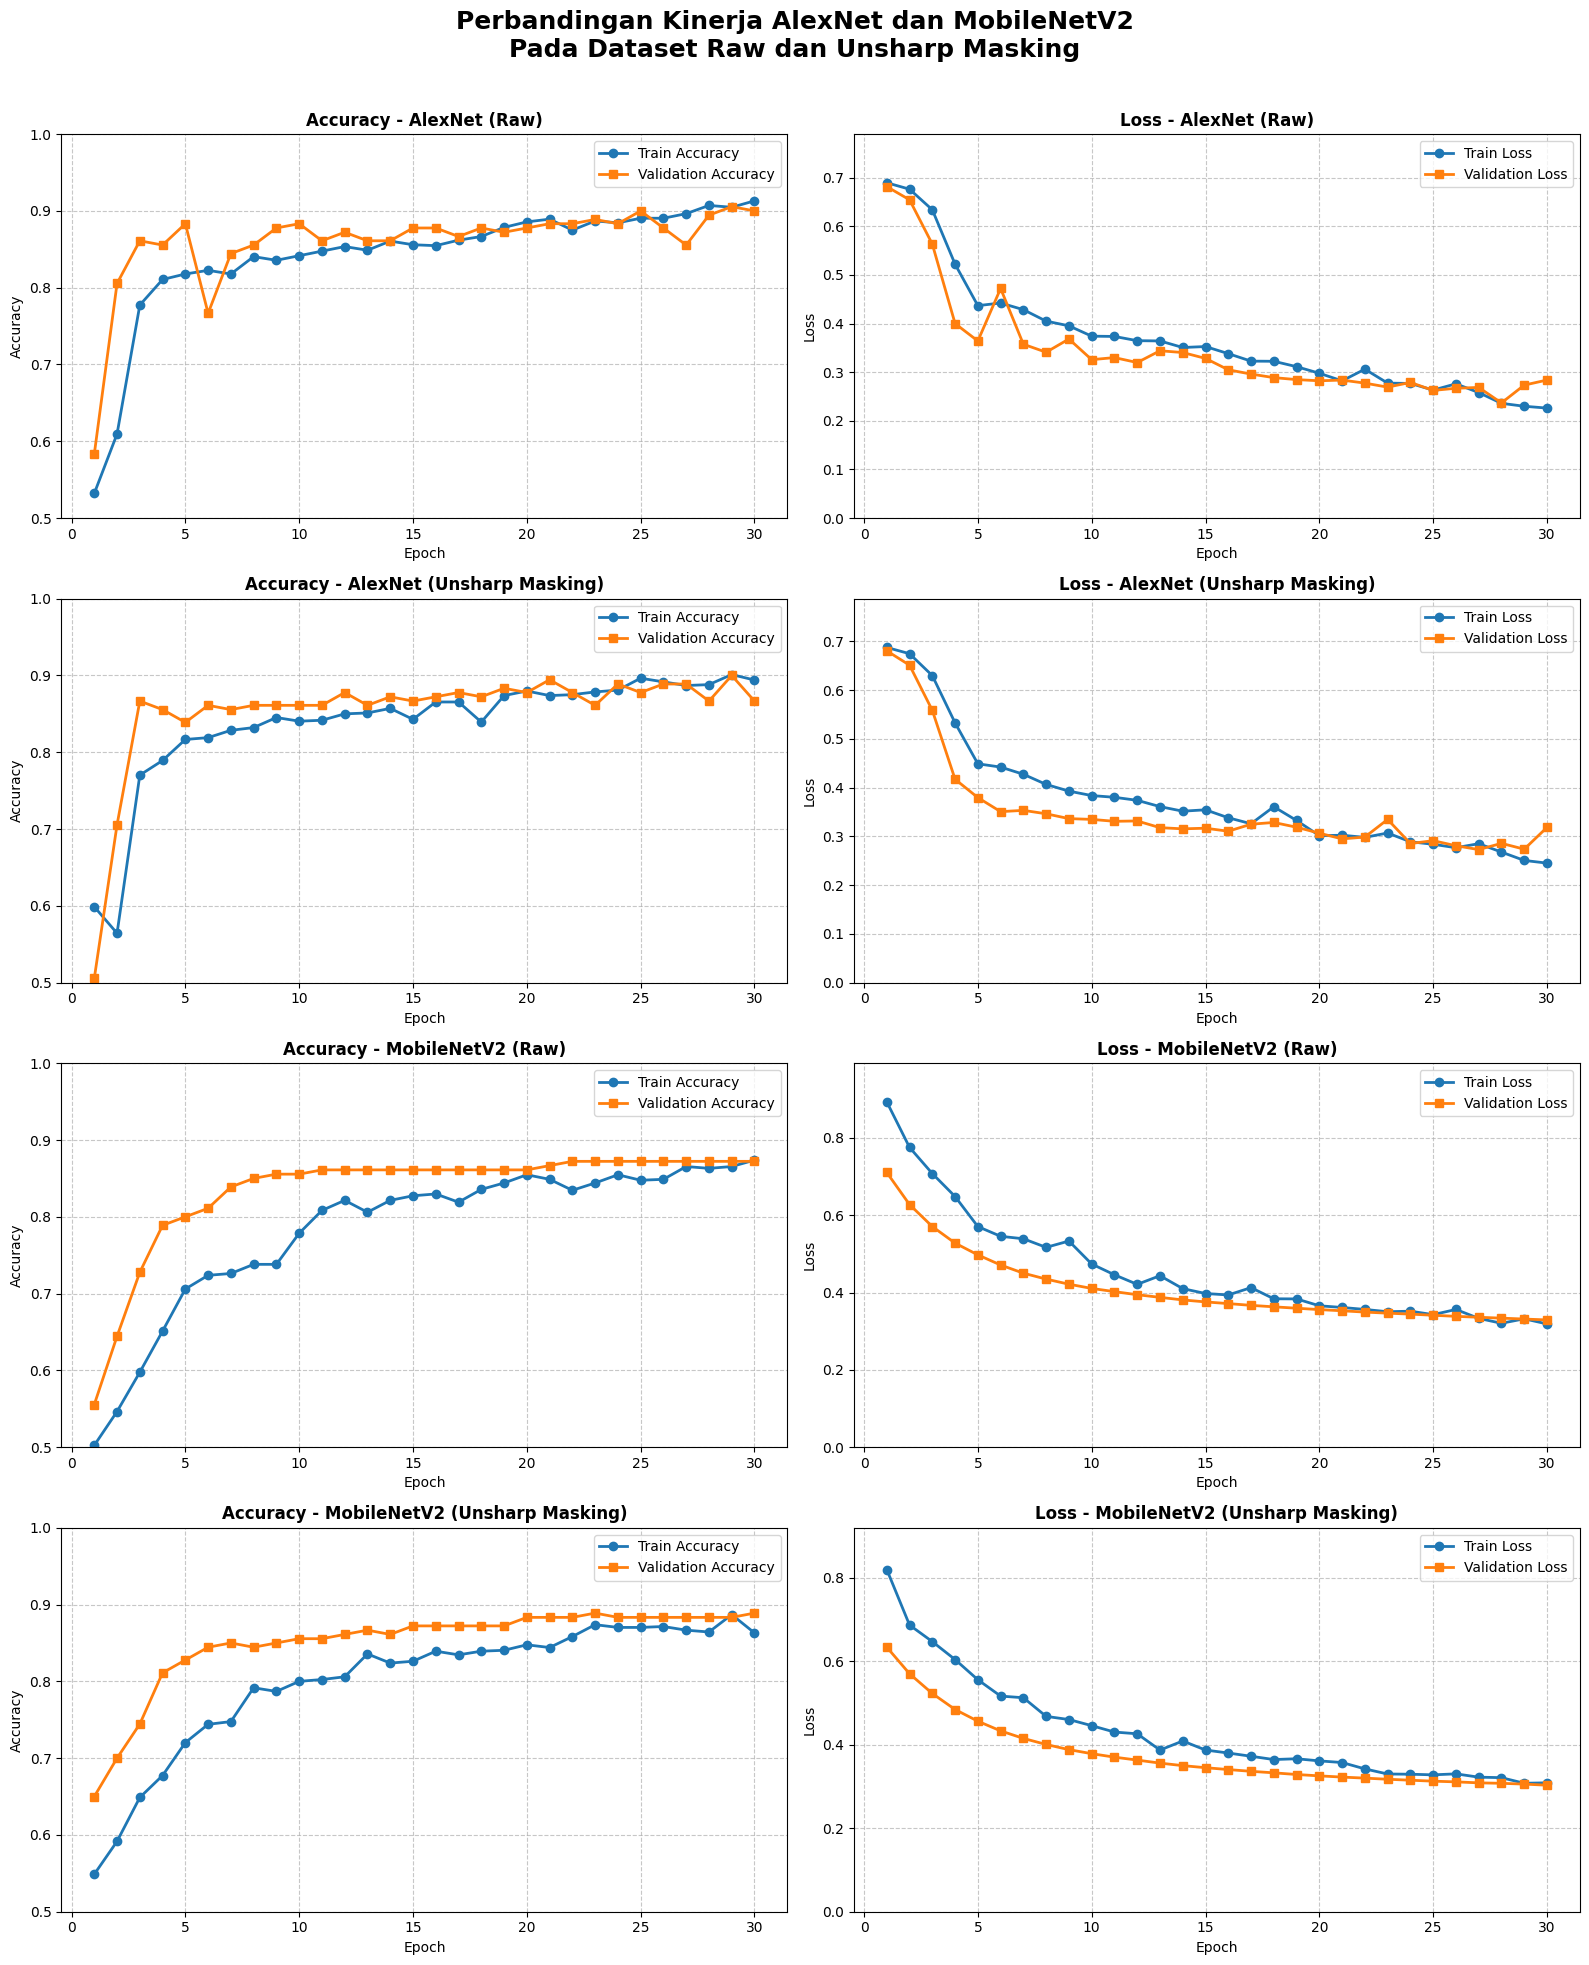

In [ ]:
# ====================================================================
# VISUALISASI SEMUA SKENARIO
# AlexNet Raw | AlexNet Sharp | MobileNetV2 Raw | MobileNetV2 Sharp
# ====================================================================

import matplotlib.pyplot as plt

histories = [
    (history_alex_raw, "AlexNet (Raw)"),
    (history_alex_sharp, "AlexNet (Unsharp Masking)"),
    (history_mobilenet_raw, "MobileNetV2 (Raw)"),
    (history_mobilenet_sharp, "MobileNetV2 (Unsharp Masking)")
]

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 20)
)

for i, (history, title) in enumerate(histories):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    # ======================================================
    # GRAFIK ACCURACY
    # ======================================================
    axes[i, 0].plot(
        epochs,
        acc,
        marker='o',
        linewidth=2,
        label='Train Accuracy'
    )

    axes[i, 0].plot(
        epochs,
        val_acc,
        marker='s',
        linewidth=2,
        label='Validation Accuracy'
    )

    axes[i, 0].set_title(
        f'Accuracy - {title}',
        fontweight='bold'
    )

    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].set_ylim(0.5, 1.0)
    axes[i, 0].legend()
    axes[i, 0].grid(True, linestyle='--', alpha=0.7)

    # ======================================================
    # GRAFIK LOSS
    # ======================================================
    axes[i, 1].plot(
        epochs,
        loss,
        marker='o',
        linewidth=2,
        label='Train Loss'
    )

    axes[i, 1].plot(
        epochs,
        val_loss,
        marker='s',
        linewidth=2,
        label='Validation Loss'
    )

    axes[i, 1].set_title(
        f'Loss - {title}',
        fontweight='bold'
    )

    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].set_ylim(
        0,
        max(loss + val_loss) + 0.1
    )
    axes[i, 1].legend()
    axes[i, 1].grid(True, linestyle='--', alpha=0.7)


plt.suptitle(
    'Perbandingan Kinerja AlexNet dan MobileNetV2\nPada Dataset Raw dan Unsharp Masking',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()

CELL 13

In [ ]:
# ====================================================================
# EVALUASI TEST SET
# Accuracy, Loss, Precision, dan Recall
# ====================================================================

import pandas as pd

hasil = []

daftar_model = [
    ("AlexNet Raw", model_alexnet_raw, test_ds_raw),
    ("AlexNet Sharp", model_alexnet_sharp, test_ds_sharp),
    ("MobileNetV2 Raw", model_mobilenet_raw, test_ds_raw),
    ("MobileNetV2 Sharp", model_mobilenet_sharp, test_ds_sharp)
]

for nama, model, test_ds in daftar_model:

    loss, acc, precision, recall = model.evaluate(
        test_ds,
        verbose=0
    )

    hasil.append({
        "Model": nama,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(precision * 100, 2),
        "Recall (%)": round(recall * 100, 2),
        "Loss": round(loss, 4)
    })

hasil_df = pd.DataFrame(hasil)

print("===== HASIL EVALUASI TEST SET =====")
display(hasil_df)

===== HASIL EVALUASI TEST SET =====


,Model,Accuracy (%),Precision (%),Recall (%),Loss
0,AlexNet Raw,86.67,82.35,93.33,0.3061
1,AlexNet Sharp,87.22,94.67,78.89,0.3013
2,MobileNetV2 Raw,89.44,93.83,84.44,0.3059
3,MobileNetV2 Sharp,88.33,93.67,82.22,0.3074


CELL 14


AlexNet Raw
                precision    recall  f1-score   support

    Gingivitis     0.9231    0.8000    0.8571        90
Non-Gingivitis     0.8235    0.9333    0.8750        90

      accuracy                         0.8667       180
     macro avg     0.8733    0.8667    0.8661       180
  weighted avg     0.8733    0.8667    0.8661       180



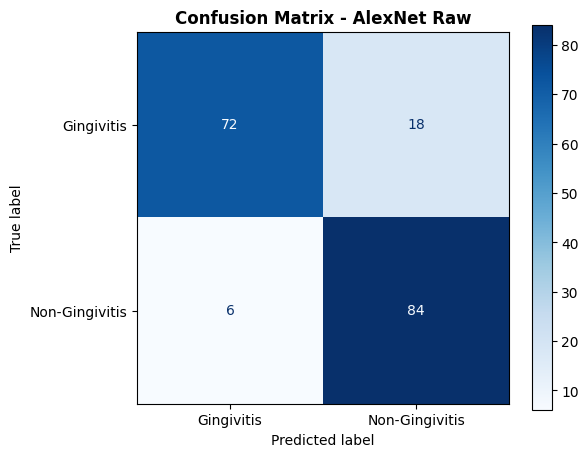


AlexNet Sharp
                precision    recall  f1-score   support

    Gingivitis     0.8190    0.9556    0.8821        90
Non-Gingivitis     0.9467    0.7889    0.8606        90

      accuracy                         0.8722       180
     macro avg     0.8829    0.8722    0.8713       180
  weighted avg     0.8829    0.8722    0.8713       180



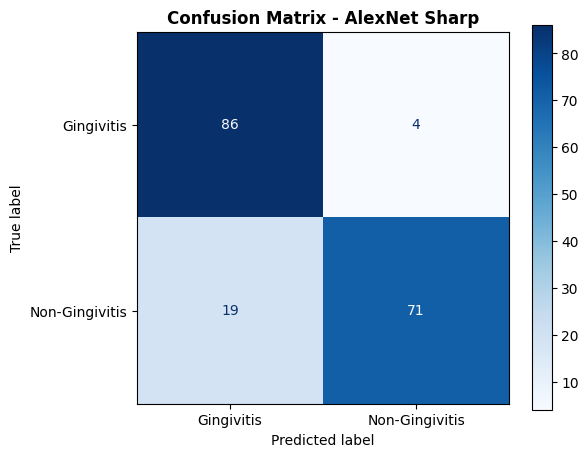


MobileNetV2 Raw
                precision    recall  f1-score   support

    Gingivitis     0.8586    0.9444    0.8995        90
Non-Gingivitis     0.9383    0.8444    0.8889        90

      accuracy                         0.8944       180
     macro avg     0.8984    0.8944    0.8942       180
  weighted avg     0.8984    0.8944    0.8942       180



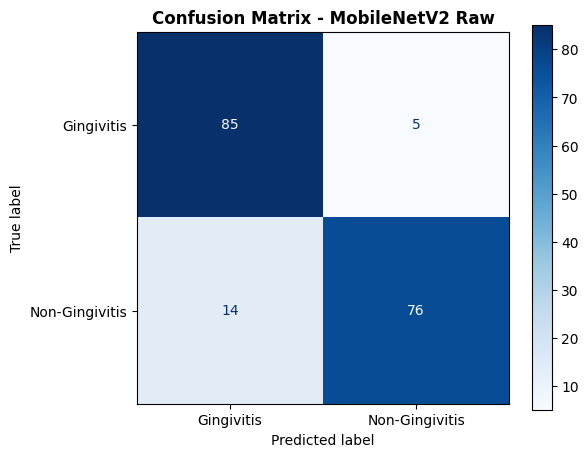


MobileNetV2 Sharp
                precision    recall  f1-score   support

    Gingivitis     0.8416    0.9444    0.8901        90
Non-Gingivitis     0.9367    0.8222    0.8757        90

      accuracy                         0.8833       180
     macro avg     0.8891    0.8833    0.8829       180
  weighted avg     0.8891    0.8833    0.8829       180



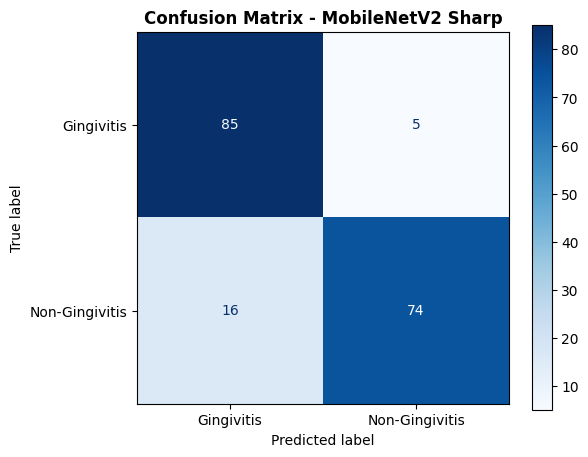


===== RINGKASAN PRECISION, RECALL, DAN F1-SCORE =====


,Model,Precision,Recall,F1-Score
0,AlexNet Raw,0.8733,0.8667,0.8661
1,AlexNet Sharp,0.8829,0.8722,0.8713
2,MobileNetV2 Raw,0.8984,0.8944,0.8942
3,MobileNetV2 Sharp,0.8891,0.8833,0.8829


In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

daftar_model = [
    ("AlexNet Raw", model_alexnet_raw, test_ds_raw),
    ("AlexNet Sharp", model_alexnet_sharp, test_ds_sharp),
    ("MobileNetV2 Raw", model_mobilenet_raw, test_ds_raw),
    ("MobileNetV2 Sharp", model_mobilenet_sharp, test_ds_sharp)
]

laporan_model = []

for nama, model, test_ds in daftar_model:

    # ======================================================
    # Ground Truth
    # ======================================================
    y_true = np.concatenate(
        [y.numpy() for x, y in test_ds]
    )

    # ======================================================
    # Prediksi
    # ======================================================
    y_pred = (
        model.predict(
            test_ds,
            verbose=0
        ) > 0.5
    ).astype(int).flatten()

    # ======================================================
    # Classification Report
    # ======================================================
    print(f"\n{'='*60}")
    print(nama)
    print(f"{'='*60}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Gingivitis",
                "Non-Gingivitis"
            ],
            digits=4,
            zero_division=0
        )
    )

    # Simpan weighted average
    report = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    laporan_model.append({
        "Model": nama,
        "Precision": round(
            report["weighted avg"]["precision"],
            4
        ),
        "Recall": round(
            report["weighted avg"]["recall"],
            4
        ),
        "F1-Score": round(
            report["weighted avg"]["f1-score"],
            4
        )
    })

    # ======================================================
    # Confusion Matrix
    # ======================================================
    cm = confusion_matrix(
        y_true,
        y_pred
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Gingivitis",
            "Non-Gingivitis"
        ]
    )

    disp.plot(
        cmap='Blues',
        values_format='d',
        ax=ax
    )

    plt.title(
        f"Confusion Matrix - {nama}",
        fontweight='bold'
    )

    plt.show()

# ==========================================================
# Tabel Ringkasan
# ==========================================================
laporan_df = pd.DataFrame(
    laporan_model
)

print("\n===== RINGKASAN PRECISION, RECALL, DAN F1-SCORE =====")
display(laporan_df)

In [ ]:
test_ds_raw
test_ds_sharp

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>